Домашнее задание – 1 (Использование VSSD)

Задача:
Изучить архитектуру VSSD (Vision Mamba with Non-Causal State Space Duality) и проверить ее эффективность на собственных данных. В новой статье которую разбирали (ICCV-25) (https://openaccess.thecvf.com/content/ICCV2025/html/Shi_VSSD_Vision_Mamba_with_Non-Causal_State_Space_Duality_ICCV_2025_paper.html) этот метод применялся для «просмотра будущего» (каждый токен в изображении вносит вклад в скрытое состояние независимо от порядка сканирования).

Инструкция:
1. Определить вычислительную конфигурацию
2. Выбрать корпус (визуальный), подходящий под задачу
3. Прогнать данные через VSSD (обучить)
4. Построить графики/визуализации
5. Обучить аналог (выбираем по желанию) и сравнить с VSSD
6. Сделать заключение

В итоге
- Код экспериментов (ноутбук или py с полным pipeline)
- Таблица и графики с результатами
- Выводы о том насколько VSSD улучшает результаты по сравнению с аналогом или аналогами для вашей задачи

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10, ImageFolder
from torch.utils.tensorboard import SummaryWriter
from einops import rearrange, repeat
import warnings
warnings.filterwarnings('ignore')

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
np.random.seed(42)

IMG_SIZE = 32
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3
NUM_CLASSES = 10

EMBED_DIM = 96
DEPTH = 4
NON_CAUSAL = True

print(f"Device: {device}")
print(f"VSSD: embed={EMBED_DIM}, depth={DEPTH}, non_causal={NON_CAUSAL}")

Device: cuda
VSSD: embed=96, depth=4, non_causal=True


In [3]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]


Train batches: 782, Test batches: 157


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange

PATCH_SIZE = 4

class VSSD_Core(nn.Module):
    def __init__(self, channels, proj_factor=2):
        super().__init__()
        inner = channels * proj_factor
        self.proj_in = nn.Linear(channels, inner * 3)
        self.proj_state = nn.Linear(channels, inner)
        self.spatial_mix = nn.Conv2d(channels, channels, 3, padding=1, groups=channels)
        self.proj_out = nn.Linear(inner, channels)
        self.gamma = nn.Parameter(torch.ones(channels) * 0.1)

    def forward(self, x, h, w):
        b, n, c = x.shape
        x_spatial = rearrange(x, 'b (h w) c -> b c h w', h=h, w=w)
        x_spatial = F.silu(self.spatial_mix(x_spatial))
        x = rearrange(x_spatial, 'b c h w -> b (h w) c')

        gates, context, weights = self.proj_in(x).chunk(3, dim=-1)
        state_feat = self.proj_state(x)

        weighted_tokens = context * torch.sigmoid(weights)
        global_repr = weighted_tokens.sum(dim=1, keepdim=True) / (n ** 0.5)

        response = global_repr * torch.sigmoid(state_feat)
        out = response * F.silu(gates)

        return x + self.gamma * self.proj_out(out)

class VSSD_Layer(nn.Module):
    def __init__(self, channels, drop_rate=0.1):
        super().__init__()
        self.pre_norm = nn.LayerNorm(channels)
        self.core = VSSD_Core(channels)
        self.post_norm = nn.LayerNorm(channels)
        self.ffn = nn.Sequential(
            nn.Linear(channels, channels * 3),
            nn.GELU(),
            nn.Dropout(drop_rate),
            nn.Linear(channels * 3, channels),
            nn.Dropout(drop_rate)
        )
        self.drop = nn.Dropout(drop_rate)

    def forward(self, x, h, w):
        x = x + self.drop(self.core(self.pre_norm(x), h, w))
        x = x + self.drop(self.ffn(self.post_norm(x)))
        return x

class VSSD_Model(nn.Module):
    def __init__(self, in_chans=3, embed_dim=128, num_blocks=4, num_classes=10):
        super().__init__()
        self.to_patch = nn.Conv2d(in_chans, embed_dim, PATCH_SIZE, PATCH_SIZE)
        self.embed_norm = nn.LayerNorm(embed_dim)

        self.stages = nn.ModuleList([
            VSSD_Layer(embed_dim) for _ in range(num_blocks)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.to_patch(x)
        b, c, h, w = x.shape
        x = rearrange(x, 'b c h w -> b (h w) c')
        x = self.embed_norm(x)

        for stage in self.stages:
            x = stage(x, h, w)

        x = self.final_norm(x)
        x = x.mean(dim=1)
        return self.classifier(x)

model = VSSD_Model(embed_dim=EMBED_DIM, num_blocks=DEPTH, num_classes=NUM_CLASSES).to(device)
print(f"VSSD model created: {sum(p.numel() for p in model.parameters()):,} params")

VSSD model created: 606,634 params


In [5]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

baseline = BaselineCNN(num_classes=NUM_CLASSES).to(device)
print(f"Baseline CNN: {sum(p.numel() for p in baseline.parameters()):,} params")

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"VSSD params: {count_params(model):,}")
print(f"Baseline params: {count_params(baseline):,}")

Baseline CNN: 94,986 params
VSSD params: 606,634
Baseline params: 94,986


In [6]:
from tqdm import tqdm
import time

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    batch_bar = tqdm(loader, desc="Training", leave=False)
    for images, labels in batch_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch_bar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{correct/total:.2%}"})
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), correct / total

def train_model(model, train_ld, test_ld, epochs, lr, device, name="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}

    print(f"\n{'='*60}")
    print(f"Training {name} | Epochs: {epochs} | LR: {lr:.1e} | Device: {device}")
    print(f"{'='*60}\n")

    for epoch in range(epochs):
        start_time = time.time()
        current_lr = optimizer.param_groups[0]["lr"]

        t_loss, t_acc = train_one_epoch(model, train_ld, criterion, optimizer, device)
        v_loss, v_acc = evaluate(model, test_ld, criterion, device)
        scheduler.step()

        elapsed = time.time() - start_time

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        history["lr"].append(current_lr)

        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Train Loss: {t_loss:.4f} Acc: {t_acc:.2%} | "
              f"Val Loss: {v_loss:.4f} Acc: {v_acc:.2%} | "
              f"LR: {current_lr:.2e} | "
              f"Time: {elapsed:.1f}s")

    print(f"\nTraining complete for {name}")
    return history

print("Training VSSD...")
vssd_history = train_model(model, train_loader, test_loader, EPOCHS, LR, device, name="VSSD")

print("\n" + "="*60 + "\n")

print("Training Baseline...")
baseline_history = train_model(baseline, train_loader, test_loader, EPOCHS, LR, device, name="Baseline")

Training VSSD...

Training VSSD | Epochs: 20 | LR: 1.0e-03 | Device: cuda



Epoch   1/20 | Train Loss: 1.6141 Acc: 39.79% | Val Loss: 1.2979 Acc: 52.20% | LR: 1.00e-03 | Time: 33.8s


Epoch   2/20 | Train Loss: 1.1771 Acc: 57.19% | Val Loss: 1.0449 Acc: 61.97% | LR: 9.94e-04 | Time: 27.9s


Epoch   3/20 | Train Loss: 0.9749 Acc: 64.86% | Val Loss: 0.9366 Acc: 66.46% | LR: 9.76e-04 | Time: 28.0s


Epoch   4/20 | Train Loss: 0.8485 Acc: 69.63% | Val Loss: 0.8731 Acc: 69.23% | LR: 9.46e-04 | Time: 27.3s


...

Epoch  16/20 | Train Loss: 0.5206 Acc: 82.51% | Val Loss: 0.6511 Acc: 77.52% | LR: 1.46e-04 | Time: 18.8s


Epoch  17/20 | Train Loss: 0.5079 Acc: 82.96% | Val Loss: 0.6409 Acc: 77.99% | LR: 9.55e-05 | Time: 19.2s


Epoch  18/20 | Train Loss: 0.4990 Acc: 83.36% | Val Loss: 0.6307 Acc: 78.26% | LR: 5.45e-05 | Time: 19.2s


Epoch  19/20 | Train Loss: 0.4922 Acc: 83.55% | Val Loss: 0.6299 Acc: 78.38% | LR: 2.45e-05 | Time: 18.7s


Epoch  20/20 | Train Loss: 0.4884 Acc: 83.78% | Val Loss: 0.6279 Acc: 78.30% | LR: 6.16e-06 | Time: 19.0s

Training complete for Baseline


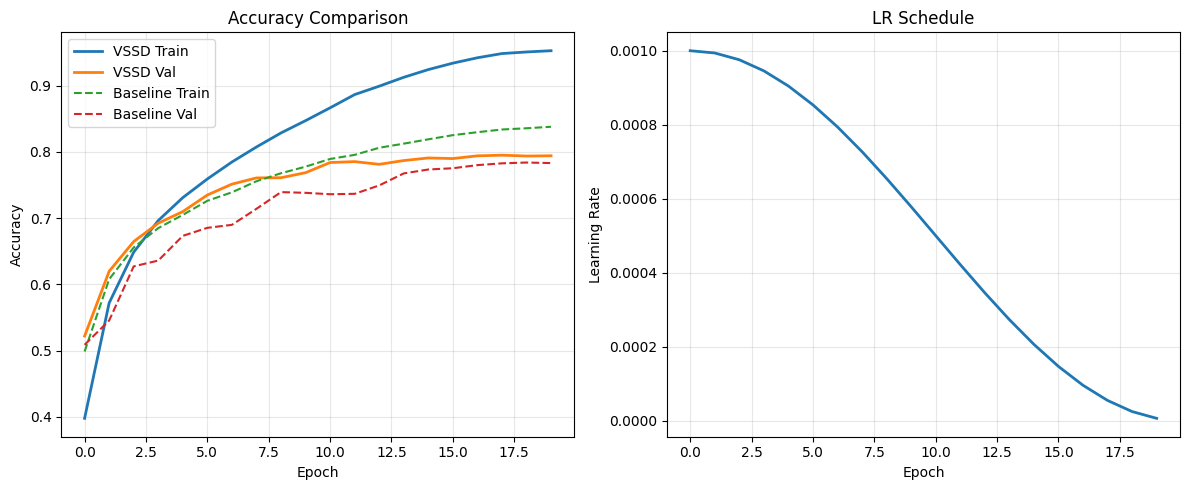

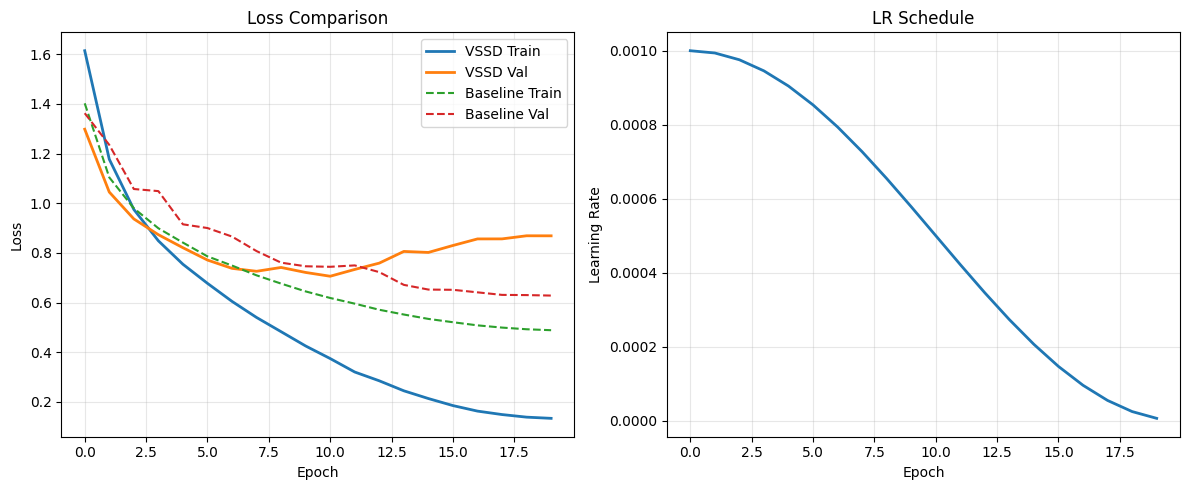


Results Summary:
   Model  Final Train Acc  Final Val Acc  Final Train Loss  Final Val Loss  Params
    VSSD          0.95250          0.794          0.133425        0.868551  606634
Baseline          0.83776          0.783          0.488424        0.627921   94986

VSSD vs Baseline validation accuracy difference: +1.10%


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_history(vssd_hist, base_hist, metric="acc"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    if metric == "acc":
        plt.plot(vssd_hist["train_acc"], label="VSSD Train", linewidth=2)
        plt.plot(vssd_hist["val_acc"], label="VSSD Val", linewidth=2)
        plt.plot(base_hist["train_acc"], label="Baseline Train", linestyle="--", linewidth=1.5)
        plt.plot(base_hist["val_acc"], label="Baseline Val", linestyle="--", linewidth=1.5)
        plt.ylabel("Accuracy")
        plt.title("Accuracy Comparison")
    else:
        plt.plot(vssd_hist["train_loss"], label="VSSD Train", linewidth=2)
        plt.plot(vssd_hist["val_loss"], label="VSSD Val", linewidth=2)
        plt.plot(base_hist["train_loss"], label="Baseline Train", linestyle="--", linewidth=1.5)
        plt.plot(base_hist["val_loss"], label="Baseline Val", linestyle="--", linewidth=1.5)
        plt.ylabel("Loss")
        plt.title("Loss Comparison")

    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(vssd_hist["lr"], label="VSSD LR", linewidth=2)
    plt.ylabel("Learning Rate")
    plt.xlabel("Epoch")
    plt.title("LR Schedule")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()

plot_history(vssd_history, baseline_history, metric="acc")
plot_history(vssd_history, baseline_history, metric="loss")

results_df = pd.DataFrame({
    "Model": ["VSSD", "Baseline"],
    "Final Train Acc": [vssd_history["train_acc"][-1], baseline_history["train_acc"][-1]],
    "Final Val Acc": [vssd_history["val_acc"][-1], baseline_history["val_acc"][-1]],
    "Final Train Loss": [vssd_history["train_loss"][-1], baseline_history["train_loss"][-1]],
    "Final Val Loss": [vssd_history["val_loss"][-1], baseline_history["val_loss"][-1]],
    "Params": [sum(p.numel() for p in model.parameters()),
               sum(p.numel() for p in baseline.parameters())]
})

print("\nResults Summary:")
print(results_df.to_string(index=False))

improvement = (vssd_history["val_acc"][-1] - baseline_history["val_acc"][-1]) * 100
print(f"\nVSSD vs Baseline validation accuracy difference: {improvement:+.2f}%")

In [8]:
"""Вывод:
Хотя прирост качества на VSSD на трейн выборке CIFAR10 был более быстрым, на валидационной выборке он показал результат чуть хуже чем Baseline модель, что может говорить о переобучении
Но зато такая модель (VSSD) достаточно быстро обучается, что немаловажно в нынешних реалиях"""

'Вывод: \nХотя прирост качества на VSSD на трейн выборке CIFAR10 был более быстрым, на валидационной выборке он показал результат чуть хуже чем Baseline модель, что может говорить о переобучении\nНо зато такая модель (VSSD) достаточно быстро обучается, что немаловажно в нынешних реалиях'